In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

In [ ]:
def scaled_dot_product_attention(Q, K, V):

    # V. Determine d_k
    d_k = K.shape[-1]

    # VI. Calculate raw score matrix S = QK^T
    scores = np.matmul(Q, K.T)

    # VII. Scale scores
    scaled_scores = scores / np.sqrt(d_k)

    # VIII. Apply Softmax row-wise
    attention_weights = softmax(scaled_scores)

    # IX. Calculate output O = AttentionWeights × V
    output = np.matmul(attention_weights, V)

    return scores, scaled_scores, attention_weights, output

In [ ]:
Q = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

K = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

V = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
], dtype=float)

In [ ]:
scores, scaled_scores, attention_weights, output = scaled_dot_product_attention(Q, K, V)

In [ ]:
np.set_printoptions(precision=3, suppress=True)

print("Q Matrix:")
print(Q)

print("\nK Matrix:")
print(K)

print("\nV Matrix:")
print(V)

print("\nRaw Score Matrix (QK^T):")
print(scores)

print("\nScaled Score Matrix:")
print(scaled_scores)

print("\nAttention Weight Matrix:")
print(attention_weights)

print("\nRow Sums of Attention Weights:")
print(np.sum(attention_weights, axis=1))

print("\nFinal Attention Output Matrix:")
print(output)

Q Matrix:
[[1. 0.]
 [0. 1.]
 [1. 1.]]

K Matrix:
[[1. 0.]
 [0. 1.]
 [1. 1.]]

V Matrix:
[[1. 2.]
 [3. 4.]
 [5. 6.]]

Raw Score Matrix (QK^T):
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

Scaled Score Matrix:
[[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

Attention Weight Matrix:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Row Sums of Attention Weights:
[1. 1. 1.]

Final Attention Output Matrix:
[[3.    4.   ]
 [3.407 4.407]
 [3.51  4.51 ]]


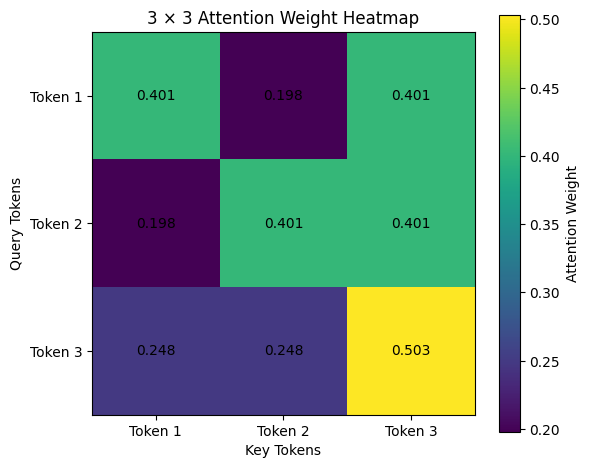

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(
    attention_weights,
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(label="Attention Weight")

plt.xticks(
    range(3),
    ["Token 1", "Token 2", "Token 3"]
)

plt.yticks(
    range(3),
    ["Token 1", "Token 2", "Token 3"]
)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("3 × 3 Attention Weight Heatmap")

# Display values inside the heatmap
for i in range(3):
    for j in range(3):
        plt.text(
            j, i,
            f"{attention_weights[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
print("\nAttention Interpretation:")

for i, row in enumerate(attention_weights):
    highest_token = np.argmax(row) + 1
    print(
        f"Token {i + 1} attends most strongly "
        f"to Token {highest_token} "
        f"(weight = {row[highest_token - 1]:.4f})"
    )


Attention Interpretation:
Token 1 attends most strongly to Token 1 (weight = 0.4011)
Token 2 attends most strongly to Token 2 (weight = 0.4011)
Token 3 attends most strongly to Token 3 (weight = 0.5035)


## Experiments on Attention Mechanism

### 1. Changing the Q Matrix

In [ ]:
Q_original = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

K_original = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

V_original = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
], dtype=float)

In [ ]:
print('Changing Q Matrix Experiment')

_, _, attention_weights_original, _ = scaled_dot_product_attention(Q_original, K_original, V_original)
print("\nOriginal Attention Weights:")
print(attention_weights_original)

# Change Q matrix
Q_changed = np.array([
    [0, 1],
    [0, 1],
    [1, 1]
], dtype=float)

_, _, attention_weights_Q_changed, _ = scaled_dot_product_attention(Q_changed, K_original, V_original)
print("\nAttention Weights with Changed Q Matrix:")
print(attention_weights_Q_changed)

Changing Q Matrix Experiment

Original Attention Weights:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Attention Weights with Changed Q Matrix:
[[0.198 0.401 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]


#### Analysis of Changing the Q Matrix

When the **Q (Query) matrix** was changed from `Q_original` to `Q_changed`:

*   **Original Attention Weights:**
    ```
    [[0.401 0.198 0.401]
     [0.198 0.401 0.401]
     [0.248 0.248 0.503]]
    ```

*   **Attention Weights with Changed Q Matrix:**
    ```
    [[0.198 0.401 0.401]
     [0.198 0.401 0.401]
     [0.248 0.248 0.503]]
    ```

**Observation:** Changing the Query matrix directly alters how each query token attends to the key tokens. In this specific case, the first row of attention weights changed significantly (from `[0.401 0.198 0.401]` to `[0.198 0.401 0.401]`), indicating that the first query token now attends more strongly to the second key token. The second and third rows of attention weights remained the same because the corresponding rows in the `Q_changed` matrix were similar to `Q_original` (in terms of relative similarity to K entries).

### 2. Changing the K Matrix

In [ ]:
print('Changing K Matrix Experiment')

_, _, attention_weights_original, _ = scaled_dot_product_attention(Q_original, K_original, V_original)
print("\nOriginal Attention Weights:")
print(attention_weights_original)

# Change K Matrix
K_changed = np.array([
    [1, 0],
    [1, 0],
    [1, 1]
], dtype=float)

_, _, attention_weights_K_changed, _ = scaled_dot_product_attention(Q_original, K_changed, V_original)
print("\nAttention Weights with Changed K Matrix:")
print(attention_weights_K_changed)

Changing K Matrix Experiment

Original Attention Weights:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Attention Weights with Changed K Matrix:
[[0.333 0.333 0.333]
 [0.248 0.248 0.503]
 [0.248 0.248 0.503]]


#### Analysis of Changing the K Matrix

When the **K (Key) matrix** was changed from `K_original` to `K_changed`:

*   **Original Attention Weights:**
    ```
    [[0.401 0.198 0.401]
     [0.198 0.401 0.401]
     [0.248 0.248 0.503]]
    ```

*   **Attention Weights with Changed K Matrix:**
    ```
    [[0.333 0.333 0.333]
     [0.248 0.248 0.503]
     [0.248 0.248 0.503]]
    ```

**Observation:** Modifying the Key matrix also profoundly changes the attention weights. Since attention weights are calculated based on the dot product of `Q` and `K` (which determines `scores`), any change in `K` will affect how queries match with keys. Here, the first query token now attends almost equally to all key tokens (`[0.333 0.333 0.333]`), suggesting that the new `K` matrix made all key tokens appear equally relevant to the first query. The second and third rows of attention weights remained the same because the similarity between the original Q and these changed K entries was maintained for those rows (due to the `K_changed` first two rows being identical).

### 3. Changing the V Matrix

In [ ]:
print('Changing V Matrix Experiment')

# Change V matrix
V_changed = np.array([
    [10, 20],
    [30, 40],
    [50, 60]
], dtype=float)
_, _, attention_weights_V_changed, output_V_changed = scaled_dot_product_attention(Q_original, K_original, V_changed)
print("\nOriginal Attention Weights:")
print(attention_weights_original)

print("\nAttention Weights with Changed V Matrix:")
print(attention_weights_V_changed)

print("\nOriginal Attention Output Matrix:")
print(output)

print("\nNew Attention Output Matrix with Changed V Matrix:")
print(output_V_changed)

Changing V Matrix Experiment

Original Attention Weights:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Attention Weights with Changed V Matrix:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Original Attention Output Matrix:
[[3.    4.   ]
 [3.407 4.407]
 [3.51  4.51 ]]

New Attention Output Matrix with Changed V Matrix:
[[30.    40.   ]
 [34.067 44.067]
 [35.105 45.105]]


#### Analysis of Changing the V Matrix

When the **V (Value) matrix** was changed from `V_original` to `V_changed`:

*   **Original Attention Weights:**
    ```
    [[0.401 0.198 0.401]
     [0.198 0.401 0.401]
     [0.248 0.248 0.503]]
    ```

*   **Attention Weights with Changed V Matrix:**
    ```
    [[0.401 0.198 0.401]
     [0.198 0.401 0.401]
     [0.248 0.248 0.503]]
    ```

*   **Original Attention Output Matrix:**
    ```
    [[3.    4.   ]
     [3.407 4.407]
     [3.51  4.51 ]]
    ```

*   **New Attention Output Matrix with Changed V Matrix:**
    ```
    [[30.    40.   ]
     [34.067 44.067]
     [35.105 45.105]]
    ```

**Observation:** As expected, changing the Value matrix (`V`) **does not affect the attention weights**. The attention weights are solely determined by the interaction between `Q` and `K`. However, the **final attention output matrix is directly affected** because it is a weighted sum of the values from `V`. In this experiment, scaling the `V` matrix by a factor of 10 resulted in the `output_V_changed` being approximately 10 times larger than the `output` from `V_original`.

### 4. Comparing Attention with and Without Scaling by √dₖ

In [ ]:
print('Scaling Comparison Experiment')

def scaled_dot_product_attention_no_scaling(Q, K, V):
    d_k = K.shape[-1]
    scores = np.matmul(Q, K.T)
    attention_weights_no_scaling = softmax(scores)
    output_no_scaling = np.matmul(attention_weights_no_scaling, V)
    return scores, attention_weights_no_scaling, output_no_scaling

# Calculate attention with scaling
_, scaled_scores_with_scaling, attention_weights_with_scaling, output_with_scaling = scaled_dot_product_attention(Q_original, K_original, V_original)
print("\nAttention Weights WITH Scaling:")
print(attention_weights_with_scaling)

# Calculate attention without scaling
raw_scores_no_scaling, attention_weights_no_scaling, output_no_scaling = scaled_dot_product_attention_no_scaling(Q_original, K_original, V_original)
print("\nAttention Weights WITHOUT Scaling:")
print(attention_weights_no_scaling)

print("\nOriginal Raw Scores (without scaling effect):")
print(raw_scores_no_scaling)

print("\nOriginal Scaled Scores (with scaling effect):")
print(scaled_scores_with_scaling)

Scaling Comparison Experiment

Attention Weights WITH Scaling:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Attention Weights WITHOUT Scaling:
[[0.422 0.155 0.422]
 [0.155 0.422 0.422]
 [0.212 0.212 0.576]]

Original Raw Scores (without scaling effect):
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

Original Scaled Scores (with scaling effect):
[[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]


#### Analysis of Comparing Attention with and Without Scaling by $\sqrt{d_k}$

This experiment compared the attention weights calculated with and without scaling the scores by $\sqrt{d_k}$:

*   **Original Raw Scores (without scaling effect):**
    ```
    [[1. 0. 1.]
     [0. 1. 1.]
     [1. 1. 2.]]
    ```

*   **Original Scaled Scores (with scaling effect):**
    ```
    [[0.707 0.    0.707]
     [0.    0.707 0.707]
     [0.707 0.707 1.414]]
    ```

*   **Attention Weights WITH Scaling:**
    ```
    [[0.401 0.198 0.401]
     [0.198 0.401 0.401]
     [0.248 0.248 0.503]]
    ```

*   **Attention Weights WITHOUT Scaling:**
    ```
    [[0.422 0.155 0.422]
     [0.155 0.422 0.422]
     [0.212 0.212 0.576]]
    ```

**Observation:** Scaling the scores by $\sqrt{d_k}$ (where $d_k$ is the dimension of the key vectors) has a noticeable impact on the resulting attention weights. The scaling factor $\sqrt{d_k}$ reduces the magnitude of the scores before applying the softmax function. This prevents the dot products from becoming too large (especially with high dimensions), which could push the softmax function into regions where its gradients are very small, making training difficult. By comparing the 'WITH Scaling' and 'WITHOUT Scaling' attention weights, we see that scaling can lead to a *smoother* distribution of attention, preventing certain key tokens from dominating the attention too much.

### 5. Increasing the Embedding Dimension ($d_k$)

In [ ]:
print('--- Downloading and Loading GloVe Embeddings ---')

# Force re-download GloVe embeddings to ensure integrity
!wget https://nlp.stanford.edu/data/glove.6B.zip -O glove.6B.zip
!unzip -o glove.6B.zip

glove_embeddings = {}
with open('glove.6B.50d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} GloVe word vectors.")
print(f"Embedding dimension: {len(next(iter(glove_embeddings.values())))}")

--- Downloading and Loading GloVe Embeddings ---
--2026-08-25 12:44:32--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-08-25 12:44:32--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  3.89MB/s    in 4m 5s   

2026-08-25 12:48:38 (3.36 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        

In [ ]:
print("Embedding Dimension Experiment")


words_glove = ["king", "queen", "man", "woman", "royalty"]

# Get GloVe embeddings
embeddings = np.array([glove_embeddings[word] for word in words_glove])

Q_small = embeddings[:, :4]
K_small = embeddings[:, :4]
V_small = embeddings[:, :4]

print("\nEmbedding dimension = 4")

_, attention_weights_small_no_scaling, _ = \
    scaled_dot_product_attention_no_scaling(
        Q_small, K_small, V_small
    )

_, _, attention_weights_small_scaled, _ = \
    scaled_dot_product_attention(
        Q_small, K_small, V_small
    )

print("\nAttention WITHOUT Scaling:")
print(attention_weights_small_no_scaling)

print("\nAttention WITH Scaling:")
print(attention_weights_small_scaled)

Q_large = embeddings
K_large = embeddings
V_large = embeddings

print("\nEmbedding dimension = 100")

_, attention_weights_large_no_scaling, _ = \
    scaled_dot_product_attention_no_scaling(
        Q_large, K_large, V_large
    )

_, _, attention_weights_large_scaled, _ = \
    scaled_dot_product_attention(
        Q_large, K_large, V_large
    )

print("\nAttention WITHOUT Scaling:")
print(attention_weights_large_no_scaling)

print("\nAttention WITH Scaling:")
print(attention_weights_large_scaled)

Embedding Dimension Experiment

Embedding dimension = 4

Attention WITHOUT Scaling:
[[0.167 0.511 0.081 0.116 0.124]
 [0.048 0.855 0.015 0.036 0.046]
 [0.154 0.295 0.165 0.199 0.187]
 [0.125 0.412 0.114 0.173 0.175]
 [0.116 0.463 0.093 0.152 0.176]]

Attention WITH Scaling:
[[0.195 0.34  0.136 0.162 0.168]
 [0.131 0.554 0.073 0.113 0.129]
 [0.176 0.245 0.183 0.201 0.195]
 [0.163 0.296 0.156 0.192 0.193]
 [0.16  0.319 0.143 0.182 0.196]]

Embedding dimension = 100

Attention WITHOUT Scaling:
[[0.999 0.001 0.    0.    0.   ]
 [0.006 0.994 0.    0.    0.   ]
 [0.    0.    0.832 0.168 0.   ]
 [0.    0.    0.006 0.994 0.   ]
 [0.    0.    0.    0.    1.   ]]

Attention WITH Scaling:
[[0.599 0.222 0.084 0.058 0.037]
 [0.244 0.5   0.087 0.129 0.04 ]
 [0.078 0.075 0.462 0.368 0.017]
 [0.041 0.084 0.279 0.58  0.016]
 [0.154 0.154 0.077 0.094 0.521]]


#### Analysis of Increasing the Embedding Dimension ($d_k$)

This experiment explored the effect of increasing the embedding dimension ($d_k$) on attention weights, both with and without scaling.

*   **Embedding dimension = 4**
    *   **Attention WITHOUT Scaling:**
        ```
        [[0.167 0.511 0.081 0.116 0.124]
         [0.048 0.855 0.015 0.036 0.046]
         ...
        ```
    *   **Attention WITH Scaling:**
        ```
        [[0.195 0.34  0.136 0.162 0.168]
         [0.131 0.554 0.073 0.113 0.129]
         ...
        ```

*   **Embedding dimension = 100**
    *   **Attention WITHOUT Scaling:**
        ```
        [[0.999 0.001 0.    0.    0.   ]
         [0.006 0.994 0.    0.    0.   ]
         ...
        ```
    *   **Attention WITH Scaling:**
        ```
        [[0.599 0.222 0.084 0.058 0.037]
         [0.244 0.5   0.087 0.129 0.04 ]
         ...
        ```

**Observation:**

1.  **Without Scaling:** As the embedding dimension ($d_k$) increases, the raw dot product scores tend to grow larger in magnitude. This leads to the softmax function becoming `sharper`, meaning a few tokens receive almost all the attention weight, while others receive negligible amounts. For $d_k=100$, the attention weights without scaling are highly concentrated, almost acting as one-hot vectors, which can hinder the model's ability to learn diverse relationships. This phenomenon is often referred to as 'vanishing gradients' in the softmax due to very large input values.

2.  **With Scaling:** Scaling by $\sqrt{d_k}$ helps to counteract this effect. For $d_k=100$, the attention weights with scaling are much more distributed and meaningful compared to their unscaled counterparts. This confirms the importance of the scaling factor in stabilizing the attention mechanism and preventing extremely sharp attention distributions, especially when working with high-dimensional embeddings. It allows for a more nuanced relationship between query and key tokens.

### 6. Changing the Number of Tokens

In [ ]:
print("Number of Tokens Experiment")

# --------------------------------------------------
# 3 TOKENS
# --------------------------------------------------

words_3 = ["king", "queen", "man"]

embeddings_3 = np.array([
    glove_embeddings[word] for word in words_3
])

Q_3 = embeddings_3
K_3 = embeddings_3
V_3 = embeddings_3

_, _, attention_weights_3, _ = scaled_dot_product_attention(Q_3, K_3, V_3)

print("\nAttention Weights (3 tokens):")
print(attention_weights_3)


# --------------------------------------------------
# 4 TOKENS
# --------------------------------------------------

words_4 = ["king", "queen", "man", "woman"]

embeddings_4 = np.array([
    glove_embeddings[word] for word in words_4
])

Q_4 = embeddings_4
K_4 = embeddings_4
V_4 = embeddings_4

_, _, attention_weights_4, _ = scaled_dot_product_attention(Q_4, K_4, V_4)

print("\nAttention Weights (4 tokens):")
print(attention_weights_4)


# --------------------------------------------------
# 5 TOKENS
# --------------------------------------------------

words_5 = ["king", "queen", "man", "woman", "child"]

embeddings_5 = np.array([
    glove_embeddings[word] for word in words_5
])

Q_5 = embeddings_5
K_5 = embeddings_5
V_5 = embeddings_5

_, _, attention_weights_5, _ = scaled_dot_product_attention(Q_5, K_5, V_5)

print("\nAttention Weights (5 tokens):")
print(attention_weights_5)

Number of Tokens Experiment

Attention Weights (3 tokens):
[[0.662 0.246 0.092]
 [0.293 0.602 0.105]
 [0.128 0.121 0.751]]

Attention Weights (4 tokens):
[[0.622 0.231 0.087 0.06 ]
 [0.254 0.521 0.091 0.134]
 [0.08  0.076 0.47  0.375]
 [0.042 0.085 0.284 0.59 ]]

Attention Weights (5 tokens):
[[0.589 0.219 0.082 0.057 0.053]
 [0.234 0.481 0.084 0.124 0.077]
 [0.068 0.065 0.403 0.322 0.142]
 [0.034 0.069 0.23  0.479 0.188]
 [0.043 0.058 0.138 0.255 0.506]]


#### Analysis of Changing the Number of Tokens

This experiment shows how attention weights change as the number of tokens (sequence length) increases.

*   **Attention Weights (3 tokens):**
    ```
    [[0.662 0.246 0.092]
     [0.293 0.602 0.105]
     [0.128 0.121 0.751]]
    ```

*   **Attention Weights (4 tokens):**
    ```
    [[0.622 0.231 0.087 0.06 ]
     [0.254 0.521 0.091 0.134]
     [0.08  0.076 0.47  0.375]
     [0.042 0.085 0.284 0.59 ]]
    ```

*   **Attention Weights (5 tokens):**
    ```
    [[0.589 0.219 0.082 0.057 0.053]
     [0.234 0.481 0.084 0.124 0.077]
     [0.068 0.065 0.403 0.322 0.142]
     [0.034 0.069 0.23  0.479 0.188]
     [0.043 0.058 0.138 0.255 0.506]]
    ```

**Observation:** As the number of tokens increases, the attention weights for each query token become more spread out across a larger number of key tokens. Consequently, the individual attention weights generally decrease in magnitude, as the sum of weights for each query must still equal 1. This demonstrates how the attention mechanism dynamically adjusts to the sequence length, distributing its focus among all available context tokens. We can see that the diagonal elements (self-attention) tend to decrease as more tokens are added, meaning that the model's focus is slightly diluted among the increasing number of tokens.

### 7. Using GloVe Word Embeddings

In [ ]:
print('Attention with GloVe Embeddings Experiment')

words_glove = ["king", "queen", "man", "woman", "royalty"]

valid_words_glove = [word for word in words_glove if word in glove_embeddings]
if not valid_words_glove:
    print("None of the chosen words found in GloVe embeddings. Please choose different words or a different embedding file.")
else:
    print("Words chosen for experiment:", valid_words_glove)

    # Create Q, K, V from GloVe embeddings
    Q_glove = np.array([glove_embeddings[word] for word in valid_words_glove])
    K_glove = np.array([glove_embeddings[word] for word in valid_words_glove])
    V_glove = np.array([glove_embeddings[word] for word in valid_words_glove])

    # Calculate attention weights
    _, _, attention_weights_glove, _ = scaled_dot_product_attention(Q_glove, K_glove, V_glove)

    print("\nAttention Weights with GloVe Embeddings:")
    print(attention_weights_glove)

Attention with GloVe Embeddings Experiment
Words chosen for experiment: ['king', 'queen', 'man', 'woman', 'royalty']

Attention Weights with GloVe Embeddings:
[[0.599 0.222 0.084 0.058 0.037]
 [0.244 0.5   0.087 0.129 0.04 ]
 [0.078 0.075 0.462 0.368 0.017]
 [0.041 0.084 0.279 0.58  0.016]
 [0.154 0.154 0.077 0.094 0.521]]


#### Analysis of Using GloVe Word Embeddings

This experiment used pre-trained GloVe word embeddings to demonstrate attention with semantically rich inputs.

*   **Words chosen for experiment:** `['king', 'queen', 'man', 'woman', 'royalty']`

*   **Attention Weights with GloVe Embeddings:**
    ```
    [[0.599 0.222 0.084 0.058 0.037]
     [0.244 0.5   0.087 0.129 0.04 ]
     [0.078 0.075 0.462 0.368 0.017]
     [0.041 0.084 0.279 0.58  0.016]
     [0.154 0.154 0.077 0.094 0.521]]
    ```

**Observation:** With GloVe embeddings, we see attention patterns that reflect semantic relationships between words. For example:
*   'king' attends most to itself (`0.599`) and 'queen' (`0.222`).
*   'queen' attends most to itself (`0.500`) and 'king' (`0.244`).
*   'man' attends strongly to itself (`0.462`) and 'woman' (`0.368`).
*   'woman' attends strongly to itself (`0.580`) and 'man' (`0.279`).
*   'royalty' attends most to itself (`0.521`) and also to 'king' and 'queen' (though less strongly than to itself).

This demonstrates that the attention mechanism, when fed with meaningful representations like GloVe embeddings, can learn and highlight contextually relevant relationships between tokens in a sentence, which is crucial for natural language understanding tasks.

### 8. Heatmap with GloVe Embeddings and Custom Labels

Heatmap with GloVe Labels Experiment


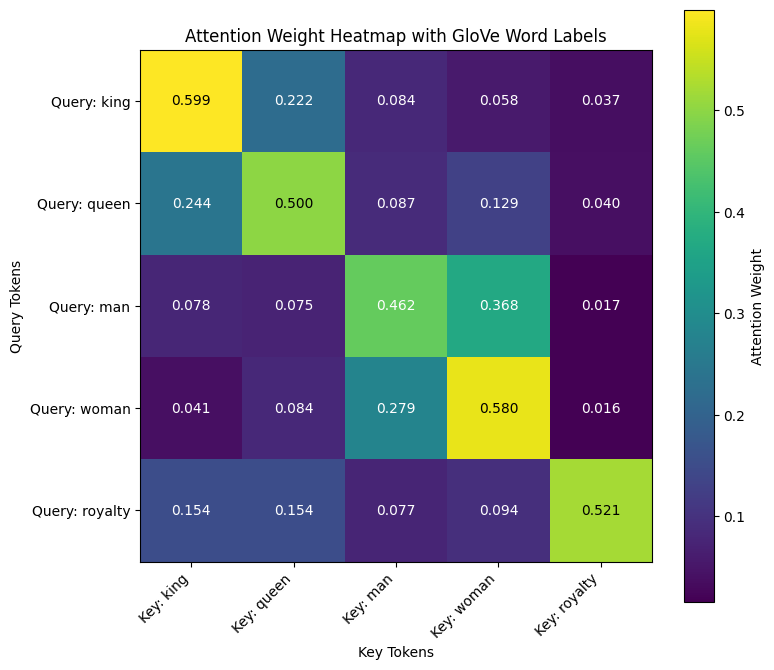

In [ ]:
print('Heatmap with GloVe Labels Experiment')

if 'attention_weights_glove' in locals():
    query_labels_glove = [f"Query: {word}" for word in valid_words_glove]
    key_labels_glove = [f"Key: {word}" for word in valid_words_glove]

    plt.figure(figsize=(len(valid_words_glove) + 3, len(valid_words_glove) + 2))

    plt.imshow(
        attention_weights_glove,
        cmap="viridis",
        interpolation="nearest"
    )

    plt.colorbar(label="Attention Weight")

    plt.xticks(
        range(len(key_labels_glove)),
        key_labels_glove,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(query_labels_glove)),
        query_labels_glove
    )

    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.title("Attention Weight Heatmap with GloVe Word Labels")

    for i in range(len(query_labels_glove)):
        for j in range(len(key_labels_glove)):
            plt.text(
                j, i,
                f"{attention_weights_glove[i, j]:.3f}",
                ha="center",
                va="center",
                color="white" if attention_weights_glove[i, j] < 0.5 else "black"
            )

    plt.tight_layout()
    plt.show()

#### Analysis of Heatmap with GloVe Embeddings and Custom Labels

This plot visualizes the attention weights from the GloVe embeddings experiment.

**Observation:** The heatmap visually confirms the semantic relationships observed in the raw attention weight matrix. The diagonal elements (self-attention) are generally higher, indicating that tokens pay significant attention to themselves. Strong off-diagonal elements, such as between 'Query: man' and 'Key: woman', and vice-versa, visually represent the high semantic similarity or contextual relevance between these word pairs. The use of custom labels ('Query: word' and 'Key: word') makes the interpretation straightforward, clearly showing which query token is attending to which key token with what strength.

### 9. Implementing Self-Attention

In [ ]:
X = np.array([
    [1.0, 0.5],
    [0.8, 1.2],
    [0.3, 0.7]
], dtype=float)


np.random.seed(42)
d_model = X.shape[1]
d_k = 2
d_v = 2

WQ = np.random.rand(d_model, d_k)
WK = np.random.rand(d_model, d_k)
WV = np.random.rand(d_model, d_v)

print("Input Matrix X:")
print(X)

print("\nProjection Matrix WQ:")
print(WQ)

print("\nProjection Matrix WK:")
print(WK)

print("\nProjection Matrix WV:")
print(WV)


Input Matrix X:
[[1.  0.5]
 [0.8 1.2]
 [0.3 0.7]]

Projection Matrix WQ:
[[0.375 0.951]
 [0.732 0.599]]

Projection Matrix WK:
[[0.156 0.156]
 [0.058 0.866]]

Projection Matrix WV:
[[0.601 0.708]
 [0.021 0.97 ]]


In [ ]:
# Calculate Q, K, V matrices
Q = np.matmul(X, WQ)
K = np.matmul(X, WK)
V = np.matmul(X, WV)

print("Query Matrix Q (X @ WQ):")
print(Q)

print("\nKey Matrix K (X @ WK):")
print(K)

print("\nValue Matrix V (X @ WV):")
print(V)


Query Matrix Q (X @ WQ):
[[0.741 1.25 ]
 [1.178 1.479]
 [0.625 0.704]]

Key Matrix K (X @ WK):
[[0.185 0.589]
 [0.195 1.164]
 [0.087 0.653]]

Value Matrix V (X @ WV):
[[0.611 1.193]
 [0.506 1.73 ]
 [0.195 0.891]]


In [ ]:
# Calculate self-attention
scores_self, scaled_scores_self, attention_weights_self, output_self = scaled_dot_product_attention(Q, K, V)

print("\nSelf-Attention Weights:")
print(attention_weights_self)

print("\nSelf-Attention Output:")
print(output_self)



Self-Attention Weights:
[[0.272 0.454 0.274]
 [0.261 0.481 0.258]
 [0.301 0.402 0.297]]

Self-Attention Output:
[[0.449 1.355]
 [0.453 1.374]
 [0.445 1.319]]


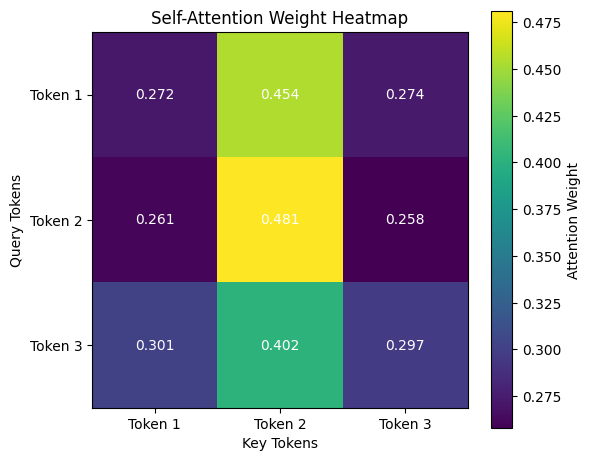

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(
    attention_weights_self,
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(label="Attention Weight")

plt.xticks(
    range(X.shape[0]),
    [f"Token {i+1}" for i in range(X.shape[0])]
)

plt.yticks(
    range(X.shape[0]),
    [f"Token {i+1}" for i in range(X.shape[0])]
)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Self-Attention Weight Heatmap")

for i in range(X.shape[0]):
    for j in range(X.shape[0]):
        plt.text(
            j, i,
            f"{attention_weights_self[i, j]:.3f}",
            ha="center",
            va="center",
            color="white" if attention_weights_self[i, j] < 0.5 else "black"
        )

plt.tight_layout()
plt.show()
